# Lab 15 — Sampling, Aliasing, and Smoothing

This lab builds hands-on intuition for the temporal and spatial resolution limits discussed in
[Chapter 15](../ch15-spatial-and-temporal-resolution.md). You will construct sine waves and
examine them with the fast Fourier transform (FFT), watch a fast signal get *aliased* to a slow one
when sampled below the Nyquist limit, alias a simulated heartbeat by sampling it at typical fMRI
TRs, and measure what spatial smoothing does to small versus large activations.

**How to run this notebook.** It runs anywhere with a standard scientific Python stack: directly
in the browser on the tutorial site, in Google Colab (badge on the chapter page), or locally
(`numpy`, `scipy`, and `matplotlib` are the only requirements). All data are simulated. Run the
cells top to bottom.


**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

rng = np.random.default_rng(2026)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False,
                     "axes.spines.right": False})


## 1. Sine waves and the FFT

A sine wave is defined by its frequency $F$ (cycles per second, Hz), amplitude, and phase
$\theta$: $y(t) = \sin(2\pi F t + \theta)$. We simulate one at a high sampling frequency
`Fs` — think of this as the "ground truth" signal before the scanner samples it.

The FFT re-expresses a time-domain signal as a sum of sine waves of different frequencies.
The magnitude of the (complex) Fourier coefficients tells us how much power the signal has at
each frequency. The highest frequency that can be represented is the **Nyquist limit**,
$F_s/2$.

*Adapted from the CANlab "Signal basics, fft, and aliasing" tutorial (canlab.github.io).*


Nyquist limit = Fs/2 = 500 Hz


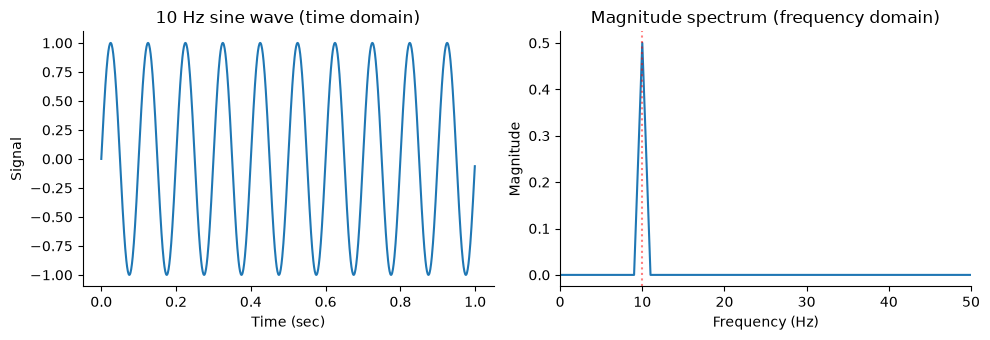

In [2]:
Fs = 1000                 # sampling frequency (samples/sec)
L = 1000                  # length of signal (samples) -> 1 second
t = np.arange(L) / Fs     # time vector (sec)

F = 10                    # frequency of the sine wave (Hz)
theta = 0                 # phase (radians)
y = np.sin(2 * np.pi * F * t + theta)

freqs = np.fft.rfftfreq(L, d=1 / Fs)   # frequencies for each FFT coefficient
mag = np.abs(np.fft.rfft(y)) / L       # magnitude spectrum

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(t, y)
axes[0].set(xlabel="Time (sec)", ylabel="Signal", title=f"{F} Hz sine wave (time domain)")
axes[1].plot(freqs, mag)
axes[1].set(xlabel="Frequency (Hz)", ylabel="Magnitude", xlim=(0, 50),
            title="Magnitude spectrum (frequency domain)")
axes[1].axvline(F, color="r", ls=":", alpha=0.5)
plt.tight_layout()

print(f"Nyquist limit = Fs/2 = {Fs / 2:.0f} Hz")


The spectrum shows a single sharp peak at 10 Hz — all of this signal's power lives at one
frequency. **Try it:** change `F` to 20, or set `theta = np.pi / 2` (which turns the sine into a
cosine). The peak moves with `F`; phase changes do not move the magnitude peak, because
magnitude discards phase information.


## 2. Aliasing: sampling a fast signal too slowly

The **Nyquist theorem** says we need more than 2 samples per cycle to represent a periodic
signal. Sampled more slowly than that, the signal does not vanish — it is *reflected around the
Nyquist frequency* and appears as a spurious slow oscillation. This is **aliasing**.

Below we take a 10 Hz sine wave (sampled densely at 1000 Hz, black) and re-sample it at three
rates. The predicted alias frequency is the distance the signal is folded back below Nyquist:
for sampling rate $F_s$, a signal at $f > F_s/2$ appears at $|f - k F_s|$ for the integer $k$
that lands it below $F_s/2$.


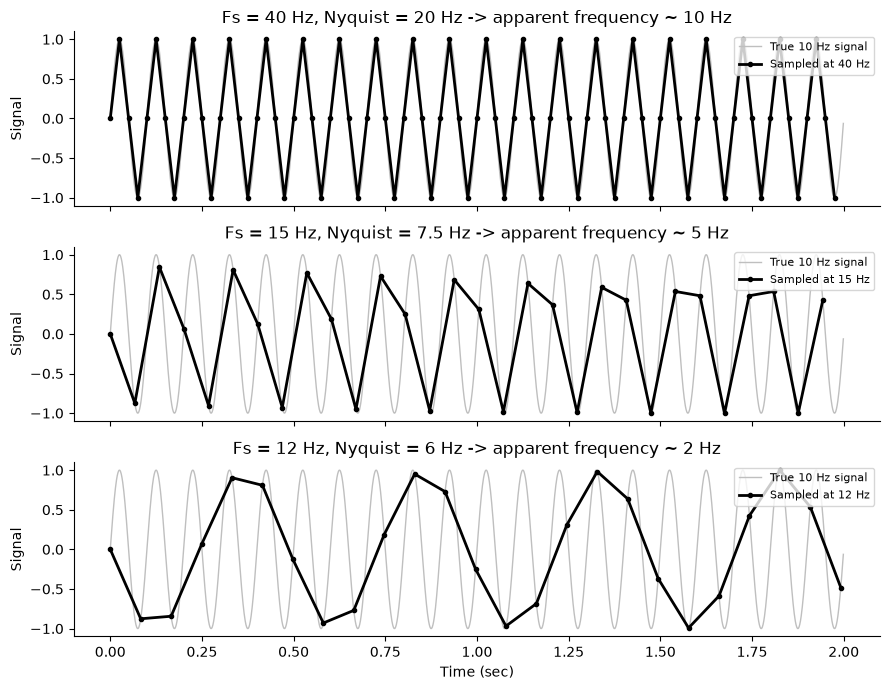

In [3]:
Fs = 1000
dur = 2.0
t = np.arange(0, dur, 1 / Fs)
F = 10
y = np.sin(2 * np.pi * F * t)

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, fs_new in zip(axes, (40, 15, 12)):
    step = round(Fs / fs_new)
    nyq = fs_new / 2
    alias = abs(F - round(F / fs_new) * fs_new)   # folded frequency
    ax.plot(t, y, color=".75", lw=1, label="True 10 Hz signal")
    ax.plot(t[::step], y[::step], "k.-", lw=2, label=f"Sampled at {fs_new} Hz")
    ax.set(ylabel="Signal",
           title=f"Fs = {fs_new} Hz, Nyquist = {nyq:g} Hz -> apparent frequency ~ {alias:g} Hz")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set(xlabel="Time (sec)")
plt.tight_layout()


At 40 Hz the samples trace the 10 Hz wave faithfully. At 15 Hz (Nyquist 7.5 Hz), the 10 Hz
signal is folded to $15 - 10 = 5$ Hz. At 12 Hz (Nyquist 6 Hz) it appears at $12 - 10 = 2$ Hz —
a slow, entirely artifactual oscillation. Let's confirm the 2 Hz alias in the frequency domain.


Spectral peak at 1.93 Hz (true signal frequency: 10 Hz)


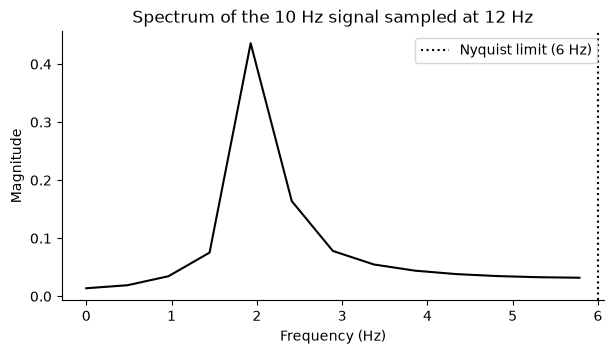

In [4]:
fs_new = 12
step = round(Fs / fs_new)
ysub = y[::step]
freqs_sub = np.fft.rfftfreq(len(ysub), d=step / Fs)
mag_sub = np.abs(np.fft.rfft(ysub)) / len(ysub)

plt.figure(figsize=(7, 3.5))
plt.plot(freqs_sub, mag_sub, "k")
plt.axvline(fs_new / 2, color="k", ls=":", label="Nyquist limit (6 Hz)")
plt.xlabel("Frequency (Hz)"); plt.ylabel("Magnitude")
plt.title("Spectrum of the 10 Hz signal sampled at 12 Hz")
plt.legend()
print(f"Spectral peak at {freqs_sub[np.argmax(mag_sub)]:.2f} Hz "
      f"(true signal frequency: {F} Hz)")


The spectrum of the under-sampled signal peaks near 2 Hz: the 10 Hz signal, 4 Hz above the
6 Hz Nyquist limit, has been reflected to 4 Hz *below* it. Once data are acquired this way,
no analysis can tell the alias apart from a genuine 2 Hz signal.

## 3. Aliasing a heartbeat at fMRI TRs

Now the fMRI version of the problem. The cardiac cycle produces a periodic artifact at roughly
1 Hz (60 beats per minute) — far faster than task-related BOLD fluctuations, which typically
live below ~0.1 Hz. Whether the heartbeat stays separable from the task depends entirely on
the TR. We simulate a spiky heartbeat with realistic beat-to-beat variability, then sample it
once per TR, as a scanner would.


Mean heart rate: 59.7 bpm


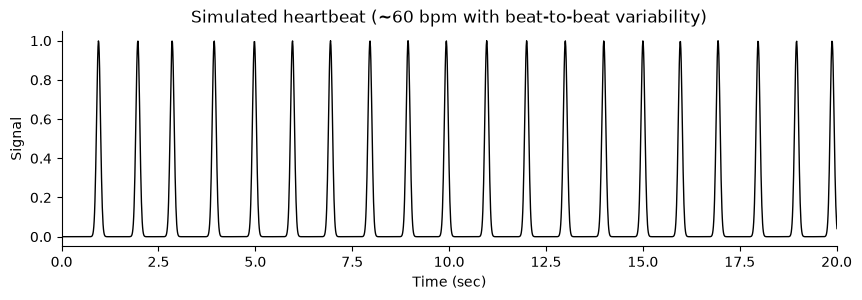

In [5]:
fs = 100                          # simulation rate (Hz) — plenty for a ~1 Hz signal
dur = 300                         # 5 minutes
t = np.arange(0, dur, 1 / fs)

# Beat times: mean interval 1 s (60 bpm) with beat-to-beat jitter
intervals = rng.normal(1.0, 0.06, size=int(dur * 1.2)).clip(0.7, 1.4)
beat_times = np.cumsum(intervals)
beat_times = beat_times[beat_times < dur - 1]

# Each beat: a brief pulse (narrow Gaussian), like a pulse-oximeter trace
heart = np.zeros_like(t)
for bt in beat_times:
    heart += np.exp(-(t - bt) ** 2 / (2 * 0.05 ** 2))

plt.figure(figsize=(10, 2.8))
plt.plot(t, heart, "k", lw=1)
plt.xlim(0, 20); plt.xlabel("Time (sec)"); plt.ylabel("Signal")
plt.title("Simulated heartbeat (~60 bpm with beat-to-beat variability)")
print(f"Mean heart rate: {60 / np.diff(beat_times).mean():.1f} bpm")


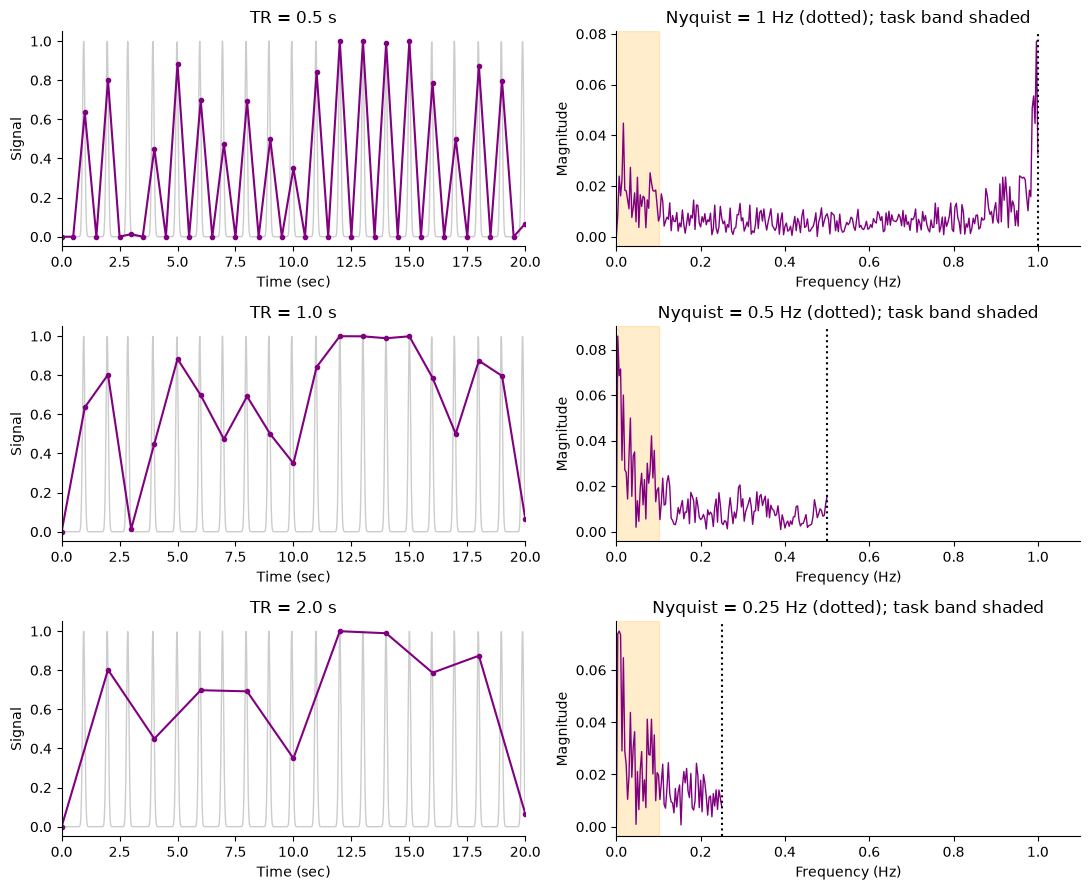

In [6]:
def sample_at_tr(signal, fs, TR):
    """Sample a densely simulated signal once per TR (volume acquisition)."""
    step = round(TR * fs)
    return signal[::step]

fig, axes = plt.subplots(3, 2, figsize=(11, 9))
for row, TR in zip(axes, (0.5, 1.0, 2.0)):
    samp = sample_at_tr(heart, fs, TR)
    ts = np.arange(len(samp)) * TR
    nyq = 1 / (2 * TR)

    # Time domain (first 20 s)
    row[0].plot(t, heart, color=".8", lw=1)
    row[0].plot(ts, samp, ".-", color="purple", lw=1.5)
    row[0].set(xlim=(0, 20), xlabel="Time (sec)", ylabel="Signal",
               title=f"TR = {TR} s")

    # Frequency domain
    freqs_s = np.fft.rfftfreq(len(samp), d=TR)
    mag_s = np.abs(np.fft.rfft(samp - samp.mean())) / len(samp)
    row[1].plot(freqs_s, mag_s, color="purple", lw=1)
    row[1].axvline(nyq, color="k", ls=":")
    row[1].axvspan(0.005, 0.1, color="orange", alpha=0.2)
    row[1].set(xlim=(0, 1.1), xlabel="Frequency (Hz)", ylabel="Magnitude",
               title=f"Nyquist = {nyq:g} Hz (dotted); task band shaded")
plt.tight_layout()


At TR = 0.5 s (Nyquist 1 Hz) most cardiac power sits at or just below 1 Hz — its own
neighborhood, far from the shaded task band, where it could be filtered out or modeled. At
TR = 1 s and especially TR = 2 s, the cardiac peak has nowhere legal to live: it is folded
below the Nyquist limit and smeared across the low frequencies, directly on top of task-related
frequencies (roughly 0.005–0.1 Hz). Let's quantify how much cardiac power lands in the task
band at each TR.


In [7]:
print("Fraction of sampled cardiac power falling in the task band (0.005-0.1 Hz):\n")
for TR in (0.4, 0.5, 1.0, 2.0, 3.0):
    samp = sample_at_tr(heart, fs, TR)
    freqs_s = np.fft.rfftfreq(len(samp), d=TR)
    power = np.abs(np.fft.rfft(samp - samp.mean())) ** 2
    in_band = power[(freqs_s > 0.005) & (freqs_s < 0.1)].sum() / power[1:].sum()
    print(f"  TR = {TR:>3} s  (Nyquist {1/(2*TR):4.2f} Hz):  {100 * in_band:5.1f} %")


Fraction of sampled cardiac power falling in the task band (0.005-0.1 Hz):

  TR = 0.4 s  (Nyquist 1.25 Hz):    1.9 %
  TR = 0.5 s  (Nyquist 1.00 Hz):   22.3 %
  TR = 1.0 s  (Nyquist 0.50 Hz):   59.7 %
  TR = 2.0 s  (Nyquist 0.25 Hz):   68.6 %
  TR = 3.0 s  (Nyquist 0.17 Hz):   70.4 %


A TR of 0.4 s keeps almost all cardiac power out of the task band. Notice the instructive edge
case at TR = 0.5 s: its Nyquist limit (1 Hz) sits exactly at the cardiac frequency, so even
there a noticeable share of power folds into low frequencies. At TR of 2–3 s a large share of it
masquerades as slow "signal". This is one reason modern accelerated (multiband) protocols
push TR below ~0.5 s: physiological noise stays above the task frequencies, where it can be
separated from neural signal — a benefit for task analyses and even more so for functional
connectivity. (With variable beat-to-beat timing the aliased power is smeared, not a clean
single peak — just as in real data.)

## 4. Is smoothing lossy? Small vs. large activations

Spatial smoothing is the temporal-sampling story's spatial cousin. Smoothing suppresses noise
and absorbs some inter-subject misalignment, but it acts as a **matched filter**: it is most
sensitive to signals at roughly the scale of the kernel, and it attenuates anything smaller.
We simulate a 1-D strip of cortex (1 voxel = 1 mm) with two activations of *equal amplitude* —
one narrow (~3.5 mm FWHM, the scale of a small nucleus) and one broad (~19 mm) — plus noise,
and smooth with a typical 8 mm FWHM Gaussian kernel.

*Inspired by `is_smoothing_lossy.m` in github.com/canlab/FMRI_simulations.*


True peak amplitude, both blobs:      2.00
Smoothed peak, narrow blob (~3.5 mm): 1.17
Smoothed peak, broad blob (~19 mm):   1.92


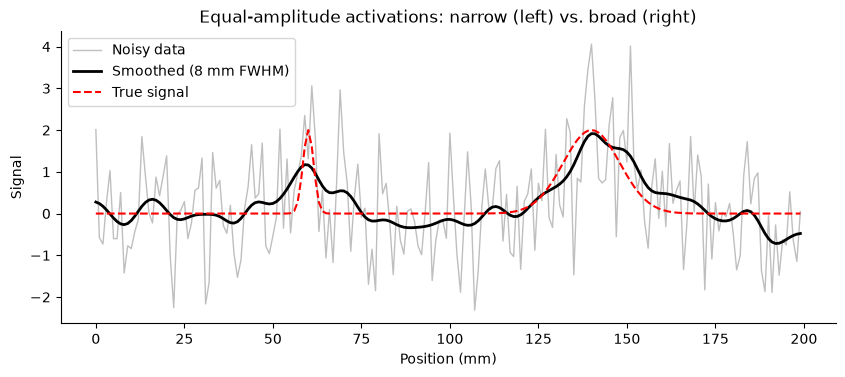

In [8]:
n_vox = 200
x = np.arange(n_vox)                                # 1 voxel = 1 mm
fwhm2sig = 1 / (2 * np.sqrt(2 * np.log(2)))         # FWHM -> Gaussian sigma

small = 2 * np.exp(-(x - 60) ** 2 / (2 * 1.5 ** 2))    # ~3.5 mm FWHM
large = 2 * np.exp(-(x - 140) ** 2 / (2 * 8 ** 2))     # ~19 mm FWHM
truth = small + large
y = truth + rng.standard_normal(n_vox)                 # noise sd = 1

kernel_fwhm = 8                                        # mm, a typical choice
y_smooth = gaussian_filter1d(y, kernel_fwhm * fwhm2sig)

plt.figure(figsize=(10, 3.8))
plt.plot(x, y, color=".75", lw=1, label="Noisy data")
plt.plot(x, y_smooth, "k", lw=2, label=f"Smoothed ({kernel_fwhm} mm FWHM)")
plt.plot(x, truth, "r--", lw=1.5, label="True signal")
plt.xlabel("Position (mm)"); plt.ylabel("Signal"); plt.legend()
plt.title("Equal-amplitude activations: narrow (left) vs. broad (right)")

print(f"True peak amplitude, both blobs:      2.00")
print(f"Smoothed peak, narrow blob (~3.5 mm): {y_smooth[50:70].max():.2f}")
print(f"Smoothed peak, broad blob (~19 mm):   {y_smooth[130:150].max():.2f}")


The broad activation survives smoothing nearly intact, while the narrow one — same true
amplitude — is flattened to a fraction of its height and could easily fall below a statistical
threshold. Smoothing traded away exactly the fine spatial scales we might care most about.

To see the tradeoff more completely, we sweep the activation width and measure two things after
smoothing: the recovered **peak amplitude** (signal attenuation) and the **peak z-score**
(detection sensitivity, averaged over noise realizations). Smoothing reduces noise, so
sensitivity can *improve* even when amplitude shrinks — but only for activations near or above
the kernel scale.


In [9]:
blob_fwhms = np.array([2, 3.5, 5, 8, 12, 19, 30])    # activation FWHM (mm)
n_sims = 200
center = n_vox // 2

print(f"{'Blob FWHM (mm)':>14} | {'smoothed peak amp':>17} | "
      f"{'peak z (raw)':>12} | {'peak z (smoothed)':>17}")
print("-" * 72)
for bf in blob_fwhms:
    blob = 2 * np.exp(-(x - center) ** 2 / (2 * (bf * fwhm2sig) ** 2))
    amp = gaussian_filter1d(blob, kernel_fwhm * fwhm2sig)[center]

    z_raw, z_sm = [], []
    for _ in range(n_sims):
        noise = rng.standard_normal(n_vox)
        z_raw.append((blob + noise)[center])
        sm = gaussian_filter1d(blob + noise, kernel_fwhm * fwhm2sig)
        sm_noise_sd = gaussian_filter1d(noise, kernel_fwhm * fwhm2sig).std()
        z_sm.append(sm[center] / sm_noise_sd)
    print(f"{bf:>14} | {amp:>17.2f} | {np.mean(z_raw):>12.1f} | {np.mean(z_sm):>17.1f}")


Blob FWHM (mm) | smoothed peak amp | peak z (raw) | peak z (smoothed)
------------------------------------------------------------------------
           2.0 |              0.49 |          2.1 |               1.7
           3.5 |              0.80 |          2.0 |               2.8
           5.0 |              1.06 |          2.1 |               3.9
           8.0 |              1.41 |          2.0 |               5.1
          12.0 |              1.66 |          2.0 |               6.2
          19.0 |              1.84 |          1.9 |               6.7
          30.0 |              1.93 |          2.1 |               7.0


Two lessons sit side by side in this table. Smoothing always *attenuates* peak amplitude for
activations smaller than the kernel — for a 2 mm activation the recovered amplitude is a small
fraction of the truth, a partial-volume-like dilution imposed by analysis rather than
acquisition. Yet the peak z-score tells a second story: because smoothing suppresses
independent voxel noise, detection sensitivity improves for activations at or above the kernel
scale, and even modest-sized activations can become easier to *detect* while being harder to
*localize precisely*. The kernel choice silently decides which spatial scales your study can
see — exactly the "effective resolution" argument of Chapter 15.

## Wrap-up

- The FFT re-expresses a time series as power at each frequency; nothing above the Nyquist
  limit $1/(2\,\mathrm{TR})$ can be represented.
- Signals faster than the Nyquist limit are folded back into low frequencies (aliasing) and
  become indistinguishable from genuine slow signals.
- At common TRs (2–3 s), cardiac signal aliases directly into task frequencies; fast
  (multiband) sampling keeps it separable.
- Spatial smoothing is a matched filter: it boosts detection of activations at its own scale
  and attenuates smaller ones, lowering the study's effective spatial resolution.

Back to the chapter: [Spatial and Temporal Resolution](../ch15-spatial-and-temporal-resolution.md).
